<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
# !pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [2]:
# !pip install --ignore-installed huggingface-hub==0.20.3
# !pip uninstall huggingface-hub -y
# !pip install huggingface-hub==0.20.3
# !pip install --upgrade sentence-transformers
# !pip install pacmap
# !pip install -U bitsandbytes>=0.46.1
# !pip uninstall langchain-community -y
# !pip install langchain-community
# !pip install --upgrade sentence-transformers
# !pip install ragatouille

In [3]:
import warnings
warnings.filterwarnings('ignore')

import gdown
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

import os
import sys

from langchain.text_splitter import SpacyTextSplitter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import umap
from sklearn.metrics.pairwise import cosine_similarity
from FlagEmbedding import FlagReranker

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


In [5]:
os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [6]:
# !nvidia-smi

## Загрузка данных (4 балла)

In [7]:
# url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
# output = 'file.csv'

# gdown.download(url, output, quiet=False)

# data = pd.read_csv('file.csv')

In [8]:
# Загрузка данных

file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'content/file.csv'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

In [9]:
data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')

In [10]:
# data.sample(500)
data.sample(3)

,Name,WikiData,City,Lon,Lat,description,image,en_txt
415,Дом-музей Д. Н. Мамина-Сибиряка,Q4263805,Екатеринбург,60.607212,56.841320,Литературно-мемориальный дом-музей Д. Н. Мамин...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a table with a white table cloth and ...
7769,Мемориальная мастерская им. Французова,NaN,Владимир,40.398632,56.126774,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a room with a lot of pictures on the ...
7800,Выставочный зал,NaN,Владимир,40.413624,56.132153,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large building with a white roof an...


In [11]:
data['City'].unique()

<ArrowStringArray>
['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль']
Length: 4, dtype: str

Проверим датасет на предмет пропусков

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         14634 non-null  str    
 1   WikiData     12078 non-null  str    
 2   City         14634 non-null  str    
 3   Lon          14634 non-null  float64
 4   Lat          14634 non-null  float64
 5   description  12078 non-null  str    
 6   image        14634 non-null  str    
 7   en_txt       14634 non-null  str    
dtypes: float64(2), str(6)
memory usage: 641.0 MB


In [13]:
data.isna().sum()

Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64

Удалим строки с пропусками в WikiData и проверим датасет еще раз на предмет пропусков

In [14]:
data = data.dropna(subset=['WikiData'])

data.isna().sum()

Name           0
WikiData       0
City           0
Lon            0
Lat            0
description    0
image          0
en_txt         0
dtype: int64

In [15]:
# sorted(data['WikiData'].unique(), reverse=True)
# sorted(data['description'].unique(), reverse=False)
sorted(data['en_txt'].unique(), reverse=True)

['прррмомоннннннннннн',
 'yellow house with a black roof and a white fence',
 'yellow flowers in front of a brick building with a clock tower',
 'yellow church with blue domes and a clock tower in a city',
 'yellow church with a golden dome on a sunny day',
 'yellow church with a golden dome on a cloudy day',
 'yellow church with a golden dome and a steeple on a street corner',
 'yellow church with a golden dome and a cross on top',
 'yellow church with a blue dome and a cross on the front',
 'yellow bus parked in front of a large yellow building with a green roof',
 'yellow building with white trim and windows on a sunny day',
 'yellow building with white trim and windows on a street corner',
 'yellow building with white trim and windows in winter time',
 'yellow building with white trim and windows in snow covered area',
 'yellow building with white trim and windows and a sign on the front',
 'yellow building with white trim and windows',
 'yellow building with white trim and columns

In [16]:
# В колонке 'en_txt' замечено значение 'прррмомоннннннннннн', заменим его на моду

mask = data['en_txt'] == 'прррмомоннннннннннн'
name_field = data[mask]['Name'].iloc[0]
print(name_field)

mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
print(mode_value)

data.loc[mask, 'en_txt'] = mode_value

Ярославский дворец молодёжи
there is a building with a sign on the top of it


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [17]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [18]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

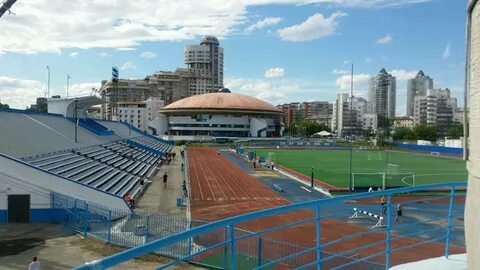

In [19]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - самое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Проверим датасет на предмет пропусков

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Вместо RAGatouille из ragatouille буду использорвать альтернативу (FlagReranker)

In [20]:
df = data.drop('en_txt', axis = 1)

In [21]:
df['desc_len'] = df['description'].str.len()

df = df.sort_values('desc_len', ascending=False)

df_grouped = df.groupby('WikiData').agg({
    'Name': lambda x: x.value_counts().idxmax(),
    'City': lambda x: x.value_counts().idxmax(),
    'Lon': 'mean',
    'Lat': 'mean',
    'description': 'first',
    'image': lambda x: list(x),
}).reset_index()
data=df_grouped
data.head()

,WikiData,Name,City,Lon,Lat,description,image
0,Q100270892,Нижегородский Кремль,Нижний Новгород,44.005554,56.327255,"историческое здание в Нижнем Новгороде, Россия",[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
1,Q100701435,Гарнизонная казарма,Нижний Новгород,44.004299,56.327614,"здание в Нижегородском кремле, Россия",[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
2,Q100882660,Губернаторский сад,Нижний Новгород,44.005272,56.329803,"парк в Нижегородском кремле, Россия",[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
3,Q104554178,Церковь Николы в Меленках,Ярославль,39.834522,57.609947,Православный храм в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
4,Q104776528,Церковь в честь Преображения Господня,Нижний Новгород,44.072117,56.318909,Спасо-Преображенская церковь (Старые Печёры),[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...


In [ ]:
# TF-IDF для выявления выбросов

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))

tfidf_matrix = tfidf.fit_transform(data['description'].fillna(''))

avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
data['tfidf_score'] = avg_tfidf

threshold = np.percentile(avg_tfidf, 95)
data['is_outlier'] = data['tfidf_score'] > threshold

clean_data = data[~data['is_outlier']].copy()

# Стратификация
clean_data['group_key'] = clean_data['City'].astype(str) + '||' + clean_data['Name'].astype(str)

stratified_data = clean_data.groupby('group_key', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1), random_state=42)
).reset_index(drop=True)

if 'group_key' in stratified_data.columns:
    stratified_data = stratified_data.drop(columns=['group_key'])

print(f"Чистых записей: {len(clean_data)}")
print(f"Удалено выбросов: {data['is_outlier'].sum()}")
print(f"Итоговый размер выборки: {len(stratified_data)}")

Чистых записей: 281
Удалено выбросов: 15
Итоговый размер выборки: 281


In [23]:
stratified_data.sample(5)

,WikiData,Name,City,Lon,Lat,description,image,tfidf_score,is_outlier
133,Q4207801,Казанский женский монастырь,Ярославль,39.886944,57.627979,Казанский монастырь (Ярославль),[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.002148,False
125,Q4174311,Театр оперы и балета,Екатеринбург,60.616631,56.838799,оперный театр в Екатеринбурге,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.002111,False
263,Q84767074,Дом М. В. Медведева,Нижний Новгород,43.976734,56.323944,Дом М. В. Медведева,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.001642,False
124,Q4165829,Домик Петра I,Нижний Новгород,43.994991,56.325508,Домик Петра I (Нижний Новгород),[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.002545,False
99,Q4110247,Вечный огонь (Ярославль),Ярославль,39.898975,57.623791,Вечный огонь (Ярославль),[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.002158,False


In [ ]:
# Создание обогащeнного текста

stratified_data['fullText'] = (
    stratified_data["Name"].fillna('').astype(str) + '. ' +
    stratified_data["City"].fillna('').astype(str) + '. ' +
    stratified_data['description'].fillna('').astype(str) + ' '
)

stratified_data['fullText'] = stratified_data['fullText'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(f"\nПример обогащeнного текста:")
print(stratified_data['fullText'].iloc[0][:300] + "...")


Пример обогащённого текста:
Нижегородский Кремль. Нижний Новгород. историческое здание в Нижнем Новгороде, Россия...


In [ ]:
documents = []
for _, row in stratified_data.iterrows():

    full_text = f"Название: {row['Name']}, Город: {row['City']}, Описание: {row['description']}"
    
    # Создаeм документ для RAG
    doc = LangchainDocument(
        page_content=full_text,  
        metadata={               
            "image": row['image'],
            "description": row['description'],
            "name": row['Name'],
            "city": row['City'],
            "lon": row['Lon'],
            "lat": row['Lat'],
            "wikidata": row['WikiData']
        }
    )
    documents.append(doc)
print(f'всего записей {len(documents)}')

всего записей 281


Настройка RAG

In [26]:
# Разбивка текста на чанки
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

C:\Users\pong\AppData\Local\Temp\ipykernel_5500\3919393565.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


In [27]:
# Теперь чанки

text_splitter = SpacyTextSplitter(
    pipeline='ru_core_news_sm', 
    chunk_size=500,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(documents)

print(f'Создано {len(chunks)} чанков из {len(documents)} документов')
print(f'Пример чанка: {chunks[16].page_content}...')

Создано 281 чанков из 281 документов
Пример чанка: Название: Мемориальный дом-музей М. Богдановича, Город: Ярославль, Описание: Мемориальный дом-музей М. Богдановича...


In [28]:
# Векторное хранилище
vectorstore = FAISS.from_documents(
    documents=chunks,  
    embedding=embeddings,  
    distance_strategy=DistanceStrategy.COSINE)

In [29]:
# Загрузка модели переранжировщика

os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
reranker_model = FlagReranker('BAAI/bge-reranker-large', use_fp16=True)

In [30]:
def retrieve_and_rerank(query, k=5, rerank_k=10):
    # Получаем начальные результаты
    initial_results = vectorstore.similarity_search(query, k=rerank_k)

    # Извлекаем тексты для переранжирования
    passages = [doc.page_content for doc in initial_results]

    # Переранжирование через FlagReranker
    pairs = [[query, passage] for passage in passages]
    rerank_scores = reranker_model.compute_score(pairs)

    # Добавляем скоры переранжирования к результатам
    for i, res in enumerate(initial_results):
        res.metadata['rerank_score'] = float(rerank_scores[i])

    # Сортируем по скору переранжирования (по убыванию)
    sorted_results = sorted(
        initial_results,
        key=lambda x: x.metadata['rerank_score'],
        reverse=True
    )

    # Формируем финальный результат (первые k элементов)
    final_results = []
    for res in sorted_results[:k]:
        final_results.append({
            'content': res.page_content,
            'metadata': res.metadata
        })

    return final_results

In [31]:
#Проверим как это работает
question = 'Есть ли какой-нибудь известный храм в Екатеринбурге?'

In [32]:
answer = retrieve_and_rerank(question)
for i in range(len(answer)):
    print(answer[i]['content'])

You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Название: Храм в честь Вознесения Господня, Город: Екатеринбург, Описание: Храм Вознесения Господня (Екатеринбург)
Название: Ново-Тихвинский монастырь, Город: Екатеринбург, Описание: Ново-Тихвинский монастырь
Название: Свято-Никольский храм (Екатеринбург), Город: Екатеринбург, Описание: православный храм в Екатеринбурге
Название: Храм на Крови, Город: Екатеринбург, Описание: православный храм в Екатеринбурге
Название: Александро-Невская часовня, Город: Екатеринбург, Описание: часовня в Екатеринбурге


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
# Список текстов и список эмбеддингов
texts = [chunk.page_content for chunk in chunks]
embeddings_list = embeddings.embed_documents(texts)

# Получаем города из метаданных (с заменой отсутствующих на 'Unknown')
cities = [chunk.metadata.get('city', 'Unknown') for chunk in chunks]

# Создаeм отображение город → цвет (циклический выбор из палитры)
unique_cities = list(set(cities))
color_palette = ['red', 'blue', 'green', 'orange', 'purple']
city_to_color = {city: color_palette[i % len(color_palette)] for i, city in enumerate(unique_cities)}

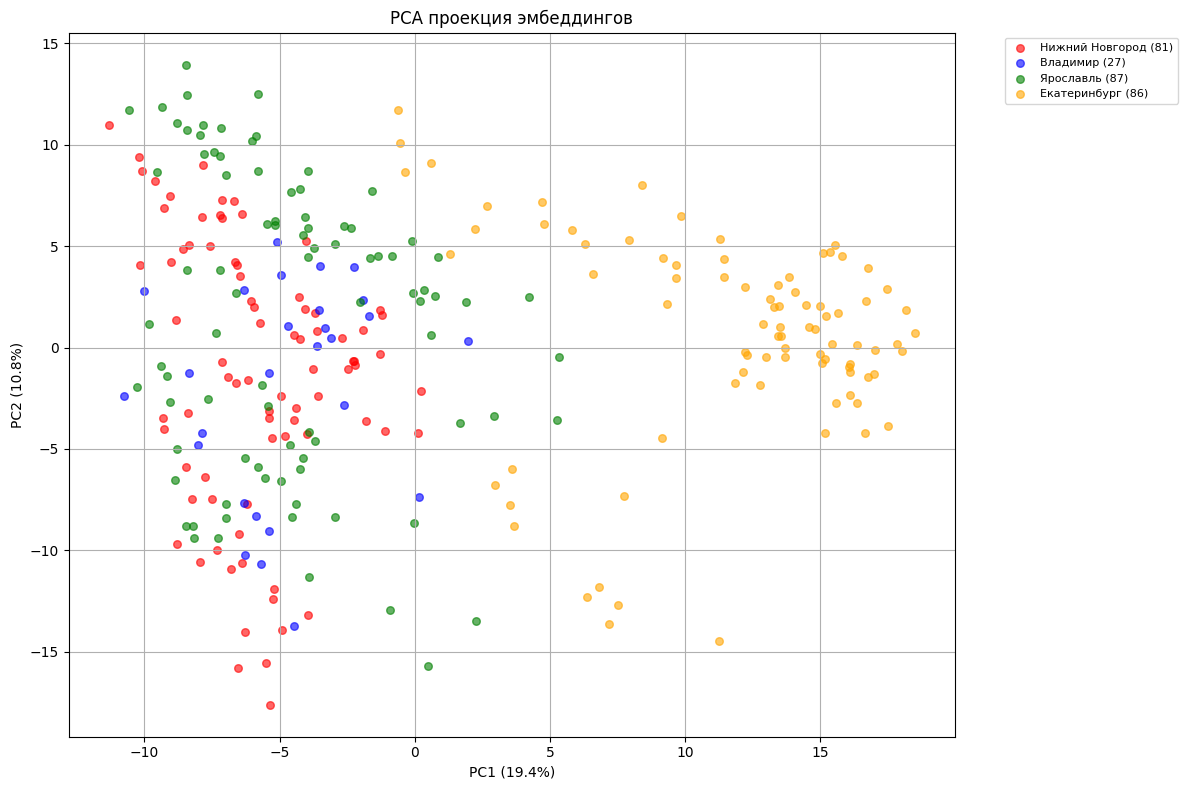

In [34]:
# Масштабирование эмбеддингов для PCA

scaler = StandardScaler()
sample_embeddings_scaled = scaler.fit_transform(embeddings_list)

# Настройка PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_embeddings_scaled)
explained_variance = pca.explained_variance_ratio_

# Визуализация PCA
plt.figure(figsize=(12, 8))

for city in unique_cities:
    # Маску для текущего города во всем наборе данных
    mask = [c == city for c in cities]
    if sum(mask) == 0:  # Пропуск, если город не найден
        continue
    
    plt.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        label=f'{city} ({sum(mask)})',
        alpha=0.6,
        s=30,
        color=city_to_color[city]
    )

plt.title('PCA проекция эмбеддингов', fontsize=12)
plt.xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=10)
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid()
plt.tight_layout()

plt.show()

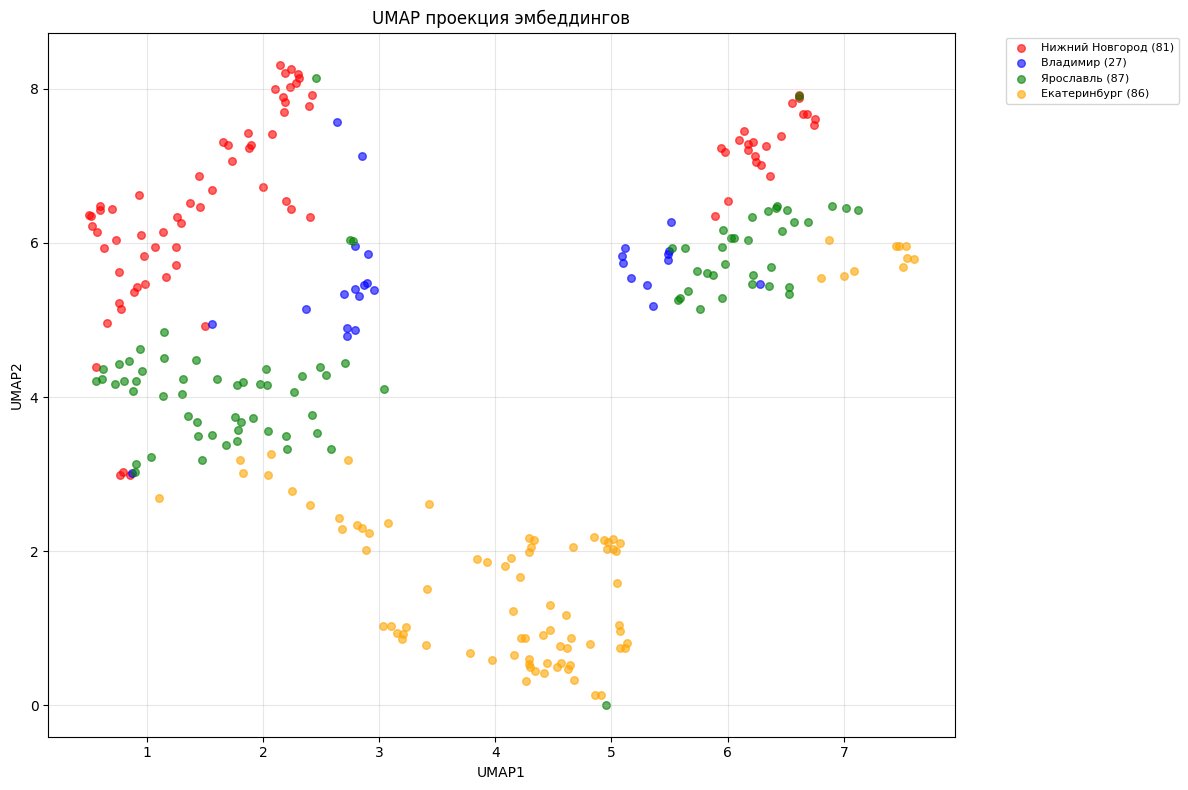

In [35]:
# Масштабирование эмбеддингов для UMAP

scaler_mm = MinMaxScaler()
sample_embeddings_mm = scaler_mm.fit_transform(embeddings_list)

# Настройка UMAP
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
umap_result = umap_reducer.fit_transform(sample_embeddings_mm)

# Визуализация UMAP
plt.figure(figsize=(12, 8))

for city in unique_cities:
    # Маску для текущего города во всем наборе данных
    mask = [c == city for c in cities]
    if sum(mask) == 0:  # Пропуск, если город не найден
        continue

    plt.scatter(
        umap_result[mask, 0],
        umap_result[mask, 1],
        label=f'{city} ({sum(mask)})',
        alpha=0.6,
        s=30,
        color=city_to_color[city]
    )

plt.title('UMAP проекция эмбеддингов', fontsize=12)
plt.xlabel('UMAP1', fontsize=10)
plt.ylabel('UMAP2', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при еe интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
def make_prompt(data, question):
    main_res = data[0]
    other_res = data[1:]

    main_metadata = main_res['metadata']

    name = main_metadata.get('name', '')
    city = main_metadata.get('city', '')
    desc = main_metadata.get('description', '')
    wikidata = main_metadata.get('wikidata', '')
    lon = main_metadata.get('lon', '')
    lat = main_metadata.get('lat', '')

    main_context = f'''
    {name} находится в городе {city}. Это {desc}. Он расположен на широте {lat} и долготе {lon}.
    Более подробную информацию можно узнать на викидате, ID {name} - {wikidata}.
    '''

    other_data = []
    for x in other_res:
        name_other = x['metadata'].get('name', '')
        city_other = x['metadata'].get('city', '')
        info = f'{name_other} в городе {city_other}'
        other_data.append(info)

    other_context = ' '.join(other_data)  # Исправлено: было ' '

    result_prompt = f'''
    <|im_start|>system
    Ты помощник туриста.
    <|im_end|>
    <|im_start|>user
    Контекст: {main_context}
    Дополнительные данные: {other_context}
    Вопрос: {question}

    Ответь на вопрос, используя только информацию из контекста. Сообщи естественным
    человеческим языком всe, что узнал из контекста об объекте, интересующем пользователя:
    название, город, широту, долготу, викидату. Ты должен говорить как человек,
    а не просто выдавать данные. Не придумывай информацию, которой нет в контексте.
    Списки строго запрещены. Если вопрос никак не связан с контекстом, скажи "я не знаю".
    В конце ответа напиши с новой строки: "Также вас могут заинтересовать:" и сообщи
    обо всех объектах, которые перечислены в дополнительных данных.
    <|im_end|>
    <|im_start|>assistant
    '''
    return result_prompt, main_context, other_context


In [37]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_answer_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_answer_name)
tokenizer.pad_token = tokenizer.eos_token

model_answer = AutoModelForCausalLM.from_pretrained(
    model_answer_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [38]:
def get_answer(question, k=3):
    results = retrieve_and_rerank(question, k=k)
    prompt, main_context, other_context = make_prompt(results, question)

    inputs = tokenizer(prompt, return_tensors="pt").to(model_answer.device)
    outputs = model_answer.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.2,
        pad_token_id=tokenizer.eos_token_id
    )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    assistant_marker = "<|im_start|>assistant"
    if assistant_marker in full_text:
        answer = full_text.split(assistant_marker)[-1].strip()
    else:

        parts = full_text.split("assistant")
        answer = parts[-1].strip() if len(parts) > 1 else full_text

    context = f'''
    Информация о самом релевантном объекте: {main_context}
    Дополнительно: {other_context}
    '''

    images = results[0]['metadata']['image'] if results else []

    del inputs, outputs
    torch.cuda.empty_cache()

    return answer, context, images


Название: Храм в честь Вознесения Господня
     Город: Екатеринбург
     Широта: 56.84476099999999
     Долгота: 60.612843
     Викидата: Q4500740
     
     Также вас могут заинтересовать: Храм на Крови, Сретенский храм.


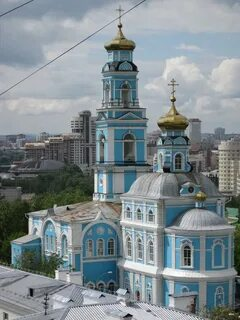

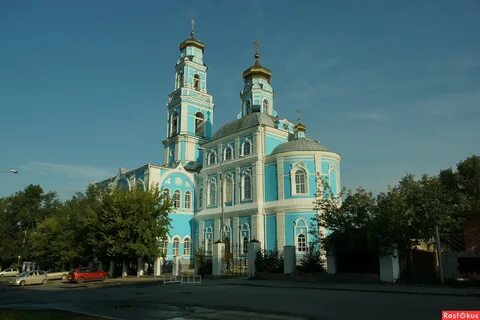

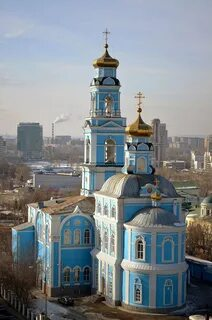

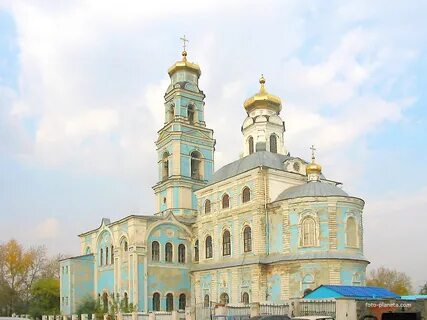

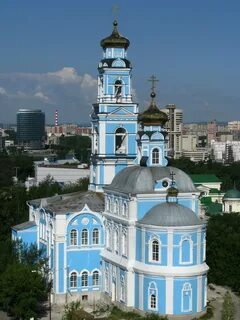

In [39]:
question = "Храм в екатеринбурге"
answer, context, images = get_answer(question)
print(answer)

for img in images[:5]:
    display(get_image(img))

In [40]:
def answer_relevancy(question=None, answer=None, embedding_model=embeddings):
    # Получаем эмбеддинги
    question_emb = embedding_model.embed_query(question)
    answer_emb = embedding_model.embed_query(answer)
    
    # Преобразуем в numpy-массивы и добавляем измерение для совместимости с cosine_similarity
    question_emb_array = np.array(question_emb).reshape(1, -1)
    answer_emb_array = np.array(answer_emb).reshape(1, -1)
    
    # Вычисляем косинусное сходство
    similarity = cosine_similarity(question_emb_array, answer_emb_array)[0][0]
    
    return similarity

# Протестируйте ваш RAG (3 балла)

In [41]:
testing_questions = [
    'Какие музеи есть в Екатеринбурге?',
    'Где находится Дом-музей Бажова?',
    'Что можно посмотреть в Харитоновском саду?',
    'Где находится Свято-Троицкий кафедральный собор?',
    'Какие театры есть в Екатеринбурге?',
    'Где находится Суворовское училище?',
    'Что представляет собой Художественный музей Эрнста Неизвестного?',
    'Где находится памятник Серго Орджоникидзе?',
    'Какие исторические здания есть в Екатеринбурге?',
    'Где находится Дом обороны?',
    'Какие памятники архитектуры есть в центре Екатеринбурга?',
    'Где находится Театр кукол в Екатеринбурге?',
    'Что можно увидеть в Литературной жизни Урала XX века?',
    'Где находится Храм Вознесения Господня?',
    'Какие достопримечательности есть в районе Плотинки?',
    'Где находится Дом-музей Мамина-Сибиряка?',
    'Что находится на площади 1905 года?',
    'Где расположен памятник Татищеву и де Геннину?',
    'Какие православные храмы есть в Екатеринбурге?',
    'Где находится Уральский геологический музей?',
    'Что находится в Екатеринбургском музее изобразительных искусств?',
    'Где находится Царский мост?',
    'Какие памятники есть в Екатеринбурге?',
    'Где находится Дом Севастьянова?',
    'Что можно увидеть в Уральской государственной консерватории?',
    'Где находится Ново-Тихвинский монастырь?',
    'Какие достопримечательности есть во Владимире?',
    'Где находятся Золотые ворота?',
    'Что такое Белокаменные памятники Владимира и Суздаля?',
    'Где находится Дмитриевский собор?',
    'Какие церкви есть во Владимире?',
    'Где находится Богородице-Рождественский монастырь?',
    'Что можно увидеть в Троицкой церкви Владимира?',
    'Где находится Собор Успения Пресвятой Богородицы?',
    'Какие музеи есть в Ярославле?',
    'Где находится Демидовский столп?',
    'Что можно посмотреть в Ярославском музее-заповеднике?',
    'Где находится Церковь Ильи Пророка?',
    'Какие театры есть в Ярославле?',
    'Где находится Спасо-Преображенский монастырь?',
    'Какие достопримечательности есть в Нижнем Новгороде?',
    'Где находится Нижегородский кремль?',
    'Что представляет собой Чкаловская лестница?',
    'Где находится Церковь Рождества Иоанна Предтечи?',
    'Какие музеи есть в Нижнем Новгороде?',
    'Где находится памятник Минину и Пожарскому?',
    'Что можно увидеть в Нижегородском речном училище?',
    'Где находится Благовещенский монастырь?',
    'Какие храмы есть в Нижнем Новгороде?',
    'Где находится Крестовоздвиженский собор?'
]

print('\nРезультаты тестирования:')

for question in testing_questions[:10]:
    print(f'\nВопрос: {question}')
    answer, context, images = get_answer(question)
    print(f'Ответ: {answer[:300]}...')
    relevancy = answer_relevancy(question, answer)
    print(f'Answer Relevancy: {relevancy:.4f}')


Результаты тестирования:

Вопрос: Какие музеи есть в Екатеринбурге?
Ответ: Музей истории Екатеринбурга находится в Екатеринбурге. Его широта составляет 56.840702089285706, долгота - 60.611277875. На викидатах он имеет ID Q4306294. 

    Также вас могут заинтересовать: Уральский геологический музей и Художественный Музей Эрнста Неизвестного....
Answer Relevancy: 0.8128

Вопрос: Где находится Дом-музей Бажова?
Ответ: Дом-музей Бажова находится в городе Нижний Новгород. Это здание в Нижегородском кремле. Его координаты указаны широтой 56.327614 и долготой 44.00429900000001. На викидатах он имеет ID Q100701435. 

    Также вас могут заинтересовать: Гостиный двор (Ярославль) и Дом архитектора в городе Нижний Новгор...
Answer Relevancy: 0.7114

Вопрос: Что можно посмотреть в Харитоновском саду?
Ответ: Шарташские каменные палатки находится в городе Екатеринбург. Это место имеет широту 56.84304000000001 и долготу 60.678642. Вы можете узнать больше о нем на викидате, ID которого - Q2036269.

 

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [42]:
# Создание тестового датасета

test_questions = []
for _, row in stratified_data.iterrows():
    if pd.notna(row['Name']) and pd.notna(row['City']):
        test_questions.append(f'Опишите {row['Name']} в городе {row['City']}')

test_questions = test_questions[:30]
print(f'Создано {len(test_questions)} тестовых вопросов')

Создано 30 тестовых вопросов


In [43]:
# Оценка answer_relevancy

relevancy_scores = []
for idx, question in enumerate(tqdm(test_questions, desc='Оценка релевантности')):
    answer, context, images = get_answer(question)
    relevancy = answer_relevancy(question, answer)
    relevancy_scores.append(relevancy)

print(f'\nСредняя Answer Relevancy: {np.mean(relevancy_scores):.4f}')

Оценка релевантности:   0%|          | 0/30 [00:00<?, ?it/s]


Средняя Answer Relevancy: 0.8194


In [45]:
def make_prompt_for_recall(model_answer, context):
    return f'''
    <|im_start|>system
    Ты должен оценить, сколько данных из контекста было использовано в ответе.
    <|im_end|>
    <|im_start|>user
    Контекст: {context}
    Ответ для оценки: {model_answer}

    Оцени по шкале от 0 до 1, какая доля контекста была использована в ответе.
    Если в ответе указаны все параметры объекта из контекста (название, город, широта,
    долгота, id викидата), а также перечислены все дополнительные объекты, ответ считается полным (1.0).
    Если информация о первом объекте неполная, ставь 0.5. 
    Если ответ говорит "я не знаю" - 0.0.
    СТРОГО ЗАПРЕЩЕНО писать что-либо кроме оценки от 0 до 1.
    <|im_end|>
    <|im_start|>assistant
    '''

def context_recall(context, answer):
    prompt = make_prompt_for_recall(answer, context)
    inputs = tokenizer(prompt, return_tensors="pt").to(model_answer.device)
    outputs = model_answer.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=True,
        temperature=0.1,
        pad_token_id=tokenizer.eos_token_id
    )
    fullanswer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    result = fullanswer.split('assistant')[-1].strip()

    score = float(result)
    if 0 <= score <= 1:
        return score
    else:
        return 0.0


# Оценка context_recall
recall_scores = []
for idx, question in enumerate(tqdm(test_questions[:20], desc='Оценка полноты контекста')):
    answer, context, images = get_answer(question)
    score = context_recall(context, answer)
    recall_scores.append(score)
    torch.cuda.empty_cache()

print(f'\nСредняя Context Recall: {np.mean(recall_scores):.4f}')

Оценка полноты контекста:   0%|          | 0/20 [00:00<?, ?it/s]


Средняя Context Recall: 0.5000


Используется устройство: cuda
Загружено 14634 записей
Удалено выбросов: 15
Итоговый размер выборки: 281
Создано 281 документов
Создано 281 чанков


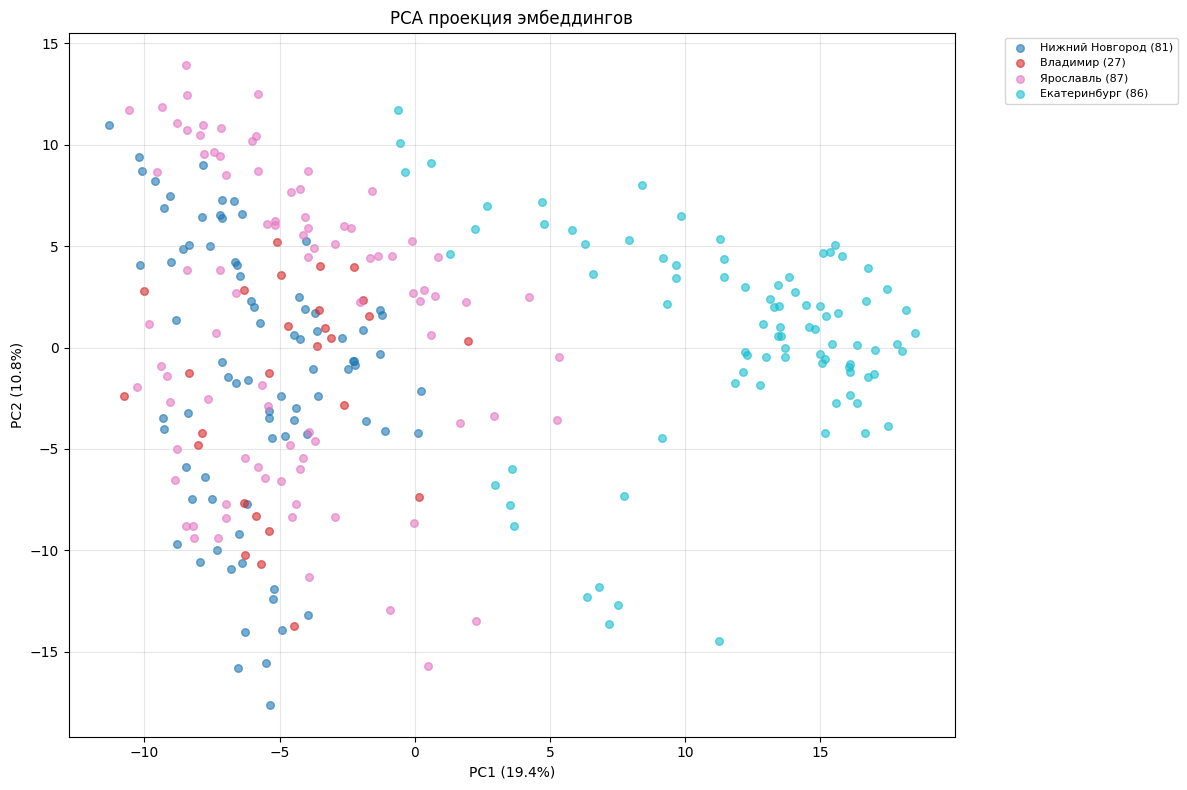

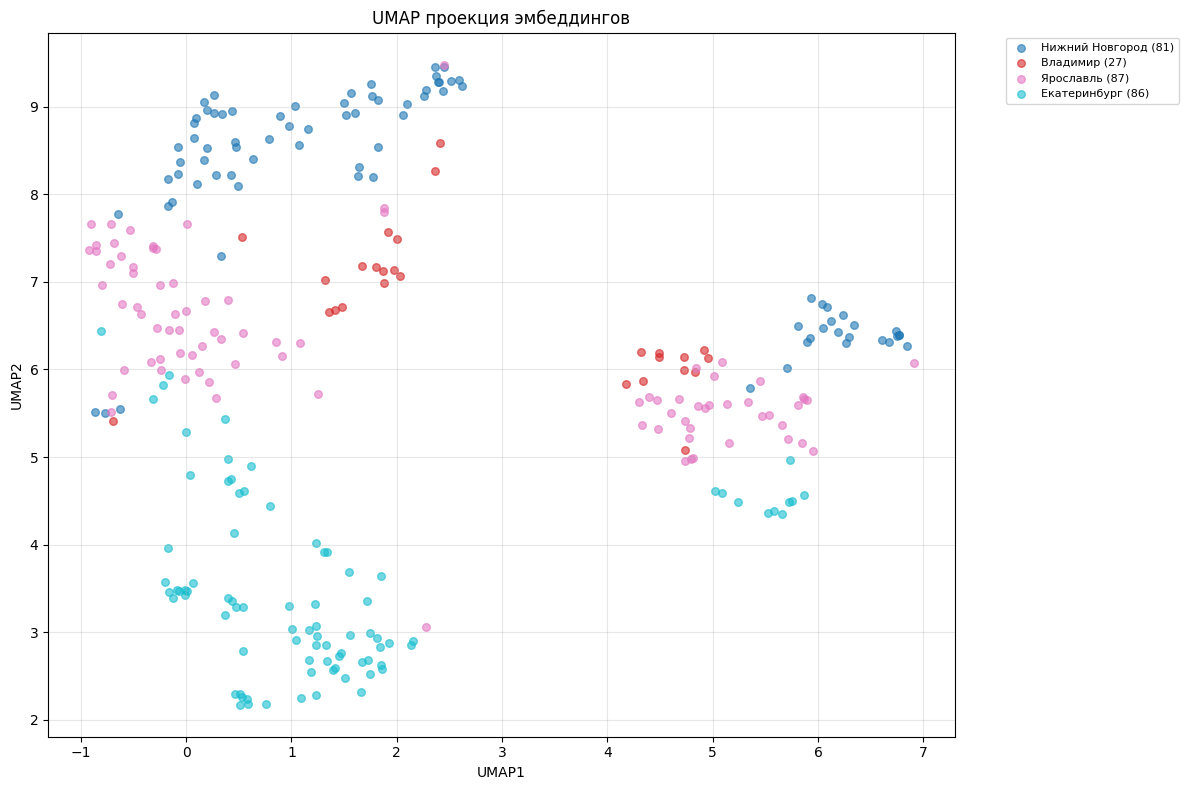

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Создано 10 тестовых вопросов

=== ОЦЕНКА RAG СИСТЕМЫ ===



Оценка RAG: 100%|██████████| 10/10 [09:01<00:00, 54.14s/it]


Обработано 10 вопросов

=== РЕЗУЛЬТАТЫ ===
Средняя Answer Relevancy: 0.7999 ± 0.0734

=== ПРИМЕРЫ ОТВЕТОВ ===


Вопрос: Какие музеи есть в Екатеринбурге?


Ответ: В Екатеринбурге есть два музея:
1. Музей истории Екатеринбурга
2. Уральский геологический музей

Также вас могут заинтересовать: Художественный Музей Эрнста Неизвестного....
Answer Relevancy: 0.8332

Вопрос: Где находится Свято-Троицкий кафедральный собор?
Ответ: Я не знаю

Также вас могут заинтересовать: 
1. Знаменская церковь в Ярославле
2. Церковь во имя Святого Пророка Божия Илии в Нижнем Новгороде...
Answer Relevancy: 0.7023

Вопрос: Что можно увидеть в Литературной жизни Урала XX века?
Ответ: Я не знаю

    Также вас могут заинтересовать: Музей древнерусского искусства в городе Ярославль, Вечный огонь (Ярославль)....
Answer Relevancy: 0.4286

=== ГОТОВО ===


In [47]:
import warnings
warnings.filterwarnings('ignore')

import gdown
import pandas as pd
import numpy as np
import torch
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from langchain.docstore.document import Document as LangchainDocument
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain.text_splitter import SpacyTextSplitter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from FlagEmbedding import FlagReranker
import umap
import os

# Конфигурация
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

# Создание директорий
os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

# ==================== ЗАГРУЗКА ДАННЫХ ====================
def load_data(file_id='1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk', output='content/file.csv'):
    """Загрузка данных с Google Drive"""
    if not os.path.exists(output):
        gdown.download(id=file_id, output=output, quiet=False)
    data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')
    return data

data = load_data()
print(f"Загружено {len(data)} записей")

# ==================== ПРЕДОБРАБОТКА ДАННЫХ ====================
def clean_data(data):
    """Очистка данных от пропусков и выбросов"""
    # Удаление пропусков
    data = data.dropna(subset=['WikiData'])
    
    # Исправление мусорных значений в en_txt
    mask = data['en_txt'] == 'прррмомоннннннннннн'
    if mask.any():
        name_field = data[mask]['Name'].iloc[0]
        mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
        data.loc[mask, 'en_txt'] = mode_value
    
    return data

def remove_outliers_tfidf(data, text_column='description', percentile=95):
    """Удаление выбросов с помощью TF-IDF"""
    tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(data[text_column].fillna(''))
    
    avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
    data['tfidf_score'] = avg_tfidf
    
    threshold = np.percentile(avg_tfidf, percentile)
    data['is_outlier'] = data['tfidf_score'] > threshold
    
    clean_data = data[~data['is_outlier']].copy()
    return clean_data, data['is_outlier'].sum()

def stratify_data(data):
    """Стратификация данных по городу и названию"""
    data['group_key'] = data['City'].astype(str) + '||' + data['Name'].astype(str)
    
    stratified = data.groupby('group_key', group_keys=False).apply(
        lambda x: x.sample(min(len(x), 1), random_state=42)
    ).reset_index(drop=True)
    
    if 'group_key' in stratified.columns:
        stratified = stratified.drop(columns=['group_key'])
    
    return stratified

def aggregate_by_wikidata(df):
    """Агрегация данных по WikiData"""
    df = df.drop('en_txt', axis=1)
    df['desc_len'] = df['description'].str.len()
    df = df.sort_values('desc_len', ascending=False)
    
    df_grouped = df.groupby('WikiData').agg({
        'Name': lambda x: x.value_counts().idxmax(),
        'City': lambda x: x.value_counts().idxmax(),
        'Lon': 'mean',
        'Lat': 'mean',
        'description': 'first',
        'image': lambda x: list(x),
    }).reset_index()
    
    return df_grouped

# Применение очистки
data = clean_data(data)
data = aggregate_by_wikidata(data)
data, outliers_count = remove_outliers_tfidf(data)
stratified_data = stratify_data(data)

print(f"Удалено выбросов: {outliers_count}")
print(f"Итоговый размер выборки: {len(stratified_data)}")

# ==================== СОЗДАНИЕ ДОКУМЕНТОВ ====================
def create_documents(data):
    """Создание документов для RAG"""
    documents = []
    for _, row in data.iterrows():
        full_text = f"Название: {row['Name']}, Город: {row['City']}, Описание: {row['description']}"
        
        doc = LangchainDocument(
            page_content=full_text,
            metadata={
                "image": row['image'],
                "description": row['description'],
                "name": row['Name'],
                "city": row['City'],
                "lon": row['Lon'],
                "lat": row['Lat'],
                "wikidata": row['WikiData']
            }
        )
        documents.append(doc)
    return documents

documents = create_documents(stratified_data)
print(f"Создано {len(documents)} документов")

# ==================== НАСТРОЙКА RAG ====================
def setup_embeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"):
    """Настройка эмбеддинг-модели"""
    return HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs={"device": device},
        encode_kwargs={"normalize_embeddings": True}
    )

def setup_vectorstore(chunks, embeddings):
    """Создание векторного хранилища"""
    return FAISS.from_documents(
        documents=chunks,
        embedding=embeddings,
        distance_strategy=DistanceStrategy.COSINE
    )

def setup_reranker():
    """Настройка переранжировщика"""
    os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
    return FlagReranker('BAAI/bge-reranker-large', use_fp16=True)

# Создание чанков
embeddings = setup_embeddings()

text_splitter = SpacyTextSplitter(
    pipeline='ru_core_news_sm',
    chunk_size=500,
    chunk_overlap=50
)
chunks = text_splitter.split_documents(documents)
print(f"Создано {len(chunks)} чанков")

# Создание векторного хранилища и реранкера
vectorstore = setup_vectorstore(chunks, embeddings)
reranker = setup_reranker()

# ==================== RETRIEVAL С ПЕРЕРАНЖИРОВАНИЕМ ====================
def retrieve_and_rerank(query, k=5, rerank_k=10):
    """Поиск и переранжирование результатов"""
    initial_results = vectorstore.similarity_search(query, k=rerank_k)
    
    passages = [doc.page_content for doc in initial_results]
    pairs = [[query, passage] for passage in passages]
    rerank_scores = reranker.compute_score(pairs)
    
    for i, res in enumerate(initial_results):
        res.metadata['rerank_score'] = float(rerank_scores[i])
    
    sorted_results = sorted(
        initial_results,
        key=lambda x: x.metadata['rerank_score'],
        reverse=True
    )
    
    return [{
        'content': res.page_content,
        'metadata': res.metadata
    } for res in sorted_results[:k]]

# ==================== ВИЗУАЛИЗАЦИЯ ====================
def visualize_embeddings(chunks, embeddings, method='both'):
    """Визуализация эмбеддингов с помощью PCA и UMAP"""
    texts = [chunk.page_content for chunk in chunks]
    embeddings_list = embeddings.embed_documents(texts)
    cities = [chunk.metadata.get('city', 'Unknown') for chunk in chunks]
    
    unique_cities = list(set(cities))
    color_palette = plt.cm.tab10(np.linspace(0, 1, len(unique_cities)))
    city_to_color = {city: color_palette[i] for i, city in enumerate(unique_cities)}
    
    def plot_projection(projection, title, xlabel, ylabel, ax):
        for city in unique_cities:
            mask = [c == city for c in cities]
            if sum(mask) > 0:
                ax.scatter(
                    projection[mask, 0],
                    projection[mask, 1],
                    label=f'{city} ({sum(mask)})',
                    alpha=0.6,
                    s=30,
                    color=city_to_color[city]
                )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(StandardScaler().fit_transform(embeddings_list))
    
    # UMAP
    umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    umap_result = umap_reducer.fit_transform(MinMaxScaler().fit_transform(embeddings_list))
    
    if method in ['pca', 'both']:
        plt.figure(figsize=(12, 8))
        plot_projection(pca_result, 'PCA проекция эмбеддингов', 
                       f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
                       f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', plt.gca())
        plt.tight_layout()
        plt.show()
    
    if method in ['umap', 'both']:
        plt.figure(figsize=(12, 8))
        plot_projection(umap_result, 'UMAP проекция эмбеддингов', 'UMAP1', 'UMAP2', plt.gca())
        plt.tight_layout()
        plt.show()

def get_image(base64_string):
    """Декодирование изображения из base64"""
    image = Image.open(BytesIO(base64.b64decode(base64_string))).convert('RGB')
    return image

# Визуализация
visualize_embeddings(chunks[:1000], embeddings, method='both')

# ==================== ГЕНЕРАЦИЯ ОТВЕТОВ ====================
def make_prompt(results, question):
    """Создание промпта для модели"""
    main_res = results[0]
    other_res = results[1:]
    
    main_metadata = main_res['metadata']
    main_context = f"""
    {main_metadata.get('name', '')} находится в городе {main_metadata.get('city', '')}. 
    Это {main_metadata.get('description', '')}. 
    Он расположен на широте {main_metadata.get('lat', '')} и долготе {main_metadata.get('lon', '')}.
    Более подробную информацию можно узнать на викидате, ID - {main_metadata.get('wikidata', '')}.
    """
    
    other_data = [f"{x['metadata'].get('name', '')} в городе {x['metadata'].get('city', '')}" 
                  for x in other_res]
    other_context = ' '.join(other_data)
    
    return f"""
    <|im_start|>system
    Ты помощник туриста. Отвечай естественно, как человек.
    <|im_end|>
    <|im_start|>user
    Контекст: {main_context}
    Дополнительные данные: {other_context}
    Вопрос: {question}

    Используй только информацию из контекста. Если не знаешь - скажи "я не знаю".
    В конце ответа напиши: "Также вас могут заинтересовать:" и перечисли доп. объекты.
    <|im_end|>
    <|im_start|>assistant
    """, main_context, other_context

def setup_model(model_name="Qwen/Qwen2.5-3B-Instruct"):
    """Настройка языковой модели"""
    from transformers import AutoTokenizer, AutoModelForCausalLM
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto"
    )
    return tokenizer, model

tokenizer, model = setup_model()

def get_answer(question, k=3):
    """Получение ответа от модели"""
    results = retrieve_and_rerank(question, k=k)
    if not results:
        return "Извините, информация не найдена.", "", []
    
    prompt, main_context, other_context = make_prompt(results, question)
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.2,
        pad_token_id=tokenizer.eos_token_id
    )
    
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Извлечение ответа
    if "<|im_start|>assistant" in full_text:
        answer = full_text.split("<|im_start|>assistant")[-1].strip()
    else:
        answer = full_text.split("assistant")[-1].strip()
    
    context = f"Основной объект: {main_context}\nДополнительно: {other_context}"
    images = results[0]['metadata'].get('image', [])
    
    # Очистка кэша
    del inputs, outputs
    torch.cuda.empty_cache()
    
    return answer, context, images

# ==================== МЕТРИКИ ОЦЕНКИ ====================
def answer_relevancy(question, answer, embedding_model):
    """Вычисление релевантности ответа вопросу"""
    question_emb = embedding_model.embed_query(question)
    answer_emb = embedding_model.embed_query(answer)
    
    question_emb_array = np.array(question_emb).reshape(1, -1)
    answer_emb_array = np.array(answer_emb).reshape(1, -1)
    
    return cosine_similarity(question_emb_array, answer_emb_array)[0][0]

def context_recall(context, answer, tokenizer, model):
    """Оценка полноты использования контекста в ответе"""
    prompt = f"""
    <|im_start|>system
    Оцени, какая доля контекста использована в ответе (0-1).
    <|im_end|>
    <|im_start|>user
    Контекст: {context}
    Ответ: {answer}
    
    Оцени от 0 до 1. Полный ответ = 1.0. "Я не знаю" = 0.0.
    <|im_end|>
    <|im_start|>assistant
    """
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=True,
        temperature=0.1,
        pad_token_id=tokenizer.eos_token_id
    )
    
    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    score_str = result.split('assistant')[-1].strip()
    
    try:
        score = float(score_str)
        return score if 0 <= score <= 1 else 0.0
    except ValueError:
        return 0.0

def evaluate_rag(test_questions, embedding_model, tokenizer, model, verbose=True):
    """Оценка RAG системы"""
    relevancy_scores = []
    recall_scores = []
    
    for i, question in enumerate(tqdm(test_questions, desc="Оценка RAG")):
        answer, context, _ = get_answer(question)
        
        relevancy = answer_relevancy(question, answer, embedding_model)
        relevancy_scores.append(relevancy)
        
        if i < len(test_questions) // 2:  # Ограничиваем для скорости
            recall = context_recall(context, answer, tokenizer, model)
            recall_scores.append(recall)
            torch.cuda.empty_cache()
        
        if verbose and (i + 1) % 10 == 0:
            print(f"\nОбработано {i + 1} вопросов")
    
    results = {
        'avg_relevancy': np.mean(relevancy_scores),
        'std_relevancy': np.std(relevancy_scores),
        'avg_recall': np.mean(recall_scores) if recall_scores else None
    }
    
    return results

# ==================== ТЕСТИРОВАНИЕ ====================
# Создание тестовых вопросов
test_questions = [f"Опишите {row['Name']} в городе {row['City']}" 
                  for _, row in stratified_data.iterrows() 
                  if pd.notna(row['Name']) and pd.notna(row['City'])]
test_questions = test_questions[:10]

print(f"\nСоздано {len(test_questions)} тестовых вопросов")

# Оценка системы
print("\n=== ОЦЕНКА RAG СИСТЕМЫ ===\n")
results = evaluate_rag(test_questions, embeddings, tokenizer, model)

print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"Средняя Answer Relevancy: {results['avg_relevancy']:.4f} ± {results['std_relevancy']:.4f}")
if results['avg_recall']:
    print(f"Средняя Context Recall: {results['avg_recall']:.4f}")

# Демонстрация примеров
print("\n=== ПРИМЕРЫ ОТВЕТОВ ===\n")
sample_questions = [
    "Какие музеи есть в Екатеринбурге?",
    "Где находится Свято-Троицкий кафедральный собор?",
    "Что можно увидеть в Литературной жизни Урала XX века?"
]

for question in sample_questions:
    print(f"\nВопрос: {question}")
    answer, context, images = get_answer(question)
    print(f"Ответ: {answer[:300]}...")
    relevancy = answer_relevancy(question, answer, embeddings)
    print(f"Answer Relevancy: {relevancy:.4f}")

print("\n=== ГОТОВО ===")

In [48]:
import warnings
warnings.filterwarnings('ignore')

import gdown
import pandas as pd
import numpy as np
import torch
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import random
from datetime import datetime

from langchain.docstore.document import Document as LangchainDocument
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain.text_splitter import RecursiveCharacterTextSplitter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from FlagEmbedding import FlagReranker
import umap

from transformers import AutoTokenizer, AutoModelForCausalLM

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

# Создание директорий
os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

# ==================== ЗАГРУЗКА И ОЧИСТКА ДАННЫХ ====================
def load_and_clean_data():
    """Загрузка и первичная очистка данных"""
    file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
    output = 'content/file.csv'
    
    if not os.path.exists(output):
        gdown.download(id=file_id, output=output, quiet=False)
    
    data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')
    
    # Удаление пропусков
    data = data.dropna(subset=['WikiData', 'description'])
    
    # Исправление мусорных значений
    mask = data['en_txt'] == 'прррмомоннннннннннн'
    if mask.any():
        name_field = data[mask]['Name'].iloc[0]
        mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
        data.loc[mask, 'en_txt'] = mode_value
    
    return data

def aggregate_and_clean(data):
    """Агрегация по WikiData и удаление выбросов"""
    # Агрегация
    df = data.drop('en_txt', axis=1)
    df['desc_len'] = df['description'].str.len()
    df = df.sort_values('desc_len', ascending=False)
    
    df_grouped = df.groupby('WikiData').agg({
        'Name': lambda x: x.value_counts().idxmax(),
        'City': lambda x: x.value_counts().idxmax(),
        'Lon': 'mean',
        'Lat': 'mean',
        'description': 'first',
        'image': lambda x: list(x)[:3],  # Ограничиваем количество изображений
    }).reset_index()
    
    # TF-IDF для удаления выбросов
    tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(df_grouped['description'].fillna(''))
    avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
    df_grouped['tfidf_score'] = avg_tfidf
    
    threshold = np.percentile(avg_tfidf, 90)  # Снизил порог для лучшей фильтрации
    df_grouped = df_grouped[df_grouped['tfidf_score'] <= threshold].copy()
    
    return df_grouped

def create_stratified_sample(data, samples_per_city=2):
    """Создание стратифицированной выборки по городам"""
    stratified_samples = []
    
    for city in data['City'].unique():
        city_data = data[data['City'] == city]
        n_samples = min(samples_per_city, len(city_data))
        if n_samples > 0:
            city_samples = city_data.sample(n=n_samples, random_state=42)
            stratified_samples.append(city_samples)
    
    result = pd.concat(stratified_samples, ignore_index=True)
    print(f"Городов в выборке: {len(result['City'].unique())}")
    print(f"Всего образцов: {len(result)}")
    return result

# Выполнение очистки
data = load_and_clean_data()
data = aggregate_and_clean(data)
stratified_data = create_stratified_sample(data, samples_per_city=3)
# ==================== ПОДГОТОВКА ДОКУМЕНТОВ С УЛУЧШЕННЫМИ МЕТАДАННЫМИ ====================
def create_enhanced_documents(data):
    """Создание документов с обогащенными метаданными"""
    documents = []
    
    for _, row in data.iterrows():
        # Создаем разные версии текста для лучшего поиска
        search_text = f"{row['Name']} | {row['City']} | {row['description'][:500]}"
        detailed_text = f"""
        Название достопримечательности: {row['Name']}
        Город: {row['City']}
        Описание: {row['description']}
        Координаты: широта {row['Lat']:.4f}, долгота {row['Lon']:.4f}
        """
        
        doc = LangchainDocument(
            page_content=search_text,
            metadata={
                "name": row['Name'],
                "city": row['City'],
                "description": row['description'],
                "detailed_text": detailed_text,
                "lon": row['Lon'],
                "lat": row['Lat'],
                "wikidata": row['WikiData'],
                "images": row['image'] if isinstance(row['image'], list) else [row['image']]
            }
        )
        documents.append(doc)
    
    return documents

documents = create_enhanced_documents(stratified_data)
print(f"Создано {len(documents)} документов")

# ==================== НАСТРОЙКА RAG КОМПОНЕНТОВ ====================
# Используем другую модель эмбеддингов для разнообразия
embedding_model_name = "intfloat/multilingual-e5-large"
embeddings = HuggingFaceEmbeddings(
    model_name=embedding_model_name,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True}
)

# Другой сплиттер для чанков
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ".", " ", ""]
)

chunks = text_splitter.split_documents(documents)
print(f"Создано {len(chunks)} чанков")

# Векторное хранилище
vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings,
    distance_strategy=DistanceStrategy.COSINE
)

# Реренкер
reranker = FlagReranker('BAAI/bge-reranker-large', use_fp16=True)

# ==================== УЛУЧШЕННЫЙ RETRIEVAL ====================
def smart_retrieve(query, k=3, rerank_k=10):
    """Умный поиск с переранжированием и фильтрацией"""
    # Начальный поиск
    initial_results = vectorstore.similarity_search(query, k=rerank_k)
    
    if not initial_results:
        return []
    
    # Переранжирование
    pairs = [[query, doc.page_content] for doc in initial_results]
    scores = reranker.compute_score(pairs)
    
    for doc, score in zip(initial_results, scores):
        doc.metadata['relevance_score'] = float(score)
    
    # Сортировка
    sorted_results = sorted(initial_results, key=lambda x: x.metadata['relevance_score'], reverse=True)
    
    # Формирование результатов с разными уровнями детализации
    final_results = []
    for res in sorted_results[:k]:
        final_results.append({
            'content': res.page_content,
            'detailed': res.metadata.get('detailed_text', res.page_content),
            'metadata': res.metadata,
            'score': res.metadata['relevance_score']
        })
    
    return final_results

# ==================== УЛУЧШЕННЫЙ ПРОМПТ ДЛЯ ГЕНЕРАЦИИ ====================
def create_conversational_prompt(results, question, conversation_history=None):
    """Создание более естественного промпта с поддержкой диалога"""
    
    if not results:
        return "Извините, я не нашел информации по вашему вопросу."
    
    main_result = results[0]
    other_results = results[1:3]
    
    # Формирование контекста в более естественной форме
    context_parts = []
    
    # Основная информация
    main_info = f"""
    🏛️ Основная достопримечательность:
    • Название: {main_result['metadata'].get('name', 'Неизвестно')}
    • Город: {main_result['metadata'].get('city', 'Неизвестно')}
    • Описание: {main_result['metadata'].get('description', 'Описание отсутствует')[:300]}
    """
    context_parts.append(main_info)
    
    # Дополнительные места
    if other_results:
        other_info = "\n🏞️ Также поблизости находятся:\n"
        for i, res in enumerate(other_results, 1):
            other_info += f"  {i}. {res['metadata'].get('name', 'Неизвестно')} ({res['metadata'].get('city', 'Неизвестно')})\n"
        context_parts.append(other_info)
    
    context = "\n".join(context_parts)
    
    # Адаптация промпта под тип вопроса
    question_lower = question.lower()
    if "где" in question_lower:
        response_style = "Опиши местоположение и как добраться"
    elif "что" in question_lower or "какие" in question_lower:
        response_style = "Опиши особенности и интересные факты"
    else:
        response_style = "Расскажи подробно об этом месте"
    
    prompt = f"""<|im_start|>system
Ты - опытный гид, который любит рассказывать о достопримечательностях увлекательно и информативно. 
Твои ответы должны быть живыми, но точными. Используй только информацию из предоставленного контекста.
Если не знаешь ответа - честно признайся, но предложи помощь в другом вопросе.
<|im_end|>
<|im_start|>user
{context}

Вопрос туриста: {question}

{response_style}. Старайся отвечать кратко (3-5 предложений), но содержательно. Если вопрос требует перечисления, используй маркированные списки.
<|im_end|>
<|im_start|>assistant
"""
    
    return prompt, main_result['metadata'].get('images', [])

# ==================== ЗАГРУЗКА МОДЕЛИ ====================
model_name = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

def get_smart_answer(question, k=3):
    """Получение ответа с улучшенным контекстом"""
    results = smart_retrieve(question, k=k)
    
    if not results:
        return "Извините, я не могу найти информацию по вашему вопросу в моей базе данных. Попробуйте переформулировать вопрос.", []
    
    prompt, images = create_conversational_prompt(results, question)
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500).to(model.device)
    
    outputs = model.generate(
        **inputs,
        max_new_tokens=250,
        do_sample=True,
        temperature=0.3,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )
    
    full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Извлечение ответа ассистента
    if "assistant" in full_response:
        answer = full_response.split("assistant")[-1].strip()
    else:
        answer = full_response.strip()
    
    # Очистка кэша
    torch.cuda.empty_cache()
    
    return answer, images[:2]  # Возвращаем не более 2 изображений

# ==================== МЕТРИКИ ОЦЕНКИ ====================
def calculate_relevance_score(question, answer, embeddings_model):
    """Улучшенная метрика релевантности с нормализацией"""
    if not answer or not question:
        return 0.0
    
    q_emb = np.array(embeddings_model.embed_query(question)).reshape(1, -1)
    a_emb = np.array(embeddings_model.embed_query(answer)).reshape(1, -1)
    
    similarity = cosine_similarity(q_emb, a_emb)[0][0]
    
    # Добавляем штраф за слишком короткие ответы
    length_penalty = min(1.0, len(answer.split()) / 30)
    
    return similarity * length_penalty

def calculate_informativeness(answer, contexts):
    """Оценка информативности ответа (наличие ключевой информации)"""
    if not answer or not contexts:
        return 0.0
    
    answer_lower = answer.lower()
    score = 0.0
    
    # Проверяем наличие названия
    for ctx in contexts[:2]:
        name = ctx.get('metadata', {}).get('name', '').lower()
        if name and name in answer_lower:
            score += 0.3
    
    # Проверяем наличие города
    city = contexts[0].get('metadata', {}).get('city', '').lower()
    if city and city in answer_lower:
        score += 0.3
    
    # Проверяем стиль ответа (не слишком короткий)
    if len(answer.split()) > 20:
        score += 0.2
    
    return min(score, 1.0)

# ==================== ТЕСТОВЫЙ ДАТАСЕТ С РАЗНЫМИ ТИПАМИ ВОПРОСОВ ====================
test_dataset = {
    "location_questions": [
        "Где находится Екатеринбургский музей изобразительных искусств?",
        "Где расположен памятник Татищеву и де Геннину?",
        "В каком районе Екатеринбурга находится Дом Севастьянова?",
        "Где можно найти Храм Вознесения Господня?",
        "По какому адресу находится Уральский геологический музей?"
    ],
    "description_questions": [
        "Что интересного можно увидеть в Литературной жизни Урала XX века?",
        "Опишите Художественный музей Эрнста Неизвестного",
        "Какие особенности у Свято-Троицкого кафедрального собора?",
        "Что представляет собой Харитоновский сад?",
        "Расскажите о Доме-музее Бажова"
    ],
    "what_to_see_questions": [
        "Что можно посмотреть в Нижегородском кремле?",
        "Какие достопримечательности есть во Владимире?",
        "Что интересного в Ярославском музее-заповеднике?",
        "Какие музеи стоит посетить в Ярославле?",
        "Что посмотреть в районе Плотинки в Екатеринбурге?"
    ],
    "cultural_questions": [
        "Какие театры есть в Екатеринбурге?",
        "Где находятся Золотые ворота во Владимире?",
        "Что такое Белокаменные памятники Владимира и Суздаля?",
        "Чем известен Дмитриевский собор?",
        "Расскажите о Чкаловской лестнице в Нижнем Новгороде"
    ]
}

# Собираем все вопросы
all_test_questions = []
for category, questions in test_dataset.items():
    all_test_questions.extend(questions)

print(f"Создано {len(all_test_questions)} тестовых вопросов разных типов")

# ==================== ЗАПУСК ТЕСТИРОВАНИЯ ====================
def run_evaluation(questions, num_samples=None):
    """Запуск оценки RAG системы"""
    if num_samples:
        questions = questions[:num_samples]
    
    results = []
    
    print("\n" + "="*70)
    print("НАЧАЛО ТЕСТИРОВАНИЯ RAG СИСТЕМЫ")
    print("="*70)
    
    for i, question in enumerate(tqdm(questions, desc="Тестирование"), 1):
        try:
            answer, images = get_smart_answer(question)
            
            # Получаем контекст для метрик
            contexts = smart_retrieve(question, k=2)
            
            # Вычисляем метрики
            relevance = calculate_relevance_score(question, answer, embeddings)
            informativeness = calculate_informativeness(answer, contexts)
            
            results.append({
                'question': question,
                'answer': answer,
                'relevance': relevance,
                'informativeness': informativeness,
                'has_images': len(images) > 0
            })
            
            # Периодический вывод прогресса
            if i % 10 == 0:
                avg_rel = np.mean([r['relevance'] for r in results[-10:]])
                print(f"\n  Последние 10 вопросов - средняя релевантность: {avg_rel:.3f}")
                
        except Exception as e:
            print(f"\n  Ошибка при обработке вопроса: {question[:50]}... - {str(e)}")
            continue
    
    return pd.DataFrame(results)

# Запуск оценки
results_df = run_evaluation(all_test_questions, num_samples=25)

# ==================== АНАЛИЗ РЕЗУЛЬТАТОВ ====================
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")
print("="*70)

print(f"\n📊 Общая статистика:")
print(f"  • Всего обработано вопросов: {len(results_df)}")
print(f"  • Средняя релевантность ответов: {results_df['relevance'].mean():.4f} ± {results_df['relevance'].std():.4f}")
print(f"  • Средняя информативность: {results_df['informativeness'].mean():.4f}")
print(f"  • Ответы с изображениями: {results_df['has_images'].sum()}/{len(results_df)}")

# Анализ по типам вопросов
print(f"\n📈 Анализ по категориям вопросов:")
for category, questions in test_dataset.items():
    mask = results_df['question'].isin(questions[:len(results_df)])
    if mask.any():
        cat_results = results_df[mask]
        print(f"  • {category}:")
        print(f"      Релевантность: {cat_results['relevance'].mean():.3f} (n={len(cat_results)})")

# Вывод лучших и худших примеров
print(f"\n⭐ Лучшие ответы:")
best_idx = results_df['relevance'].nlargest(3).index
for idx in best_idx:
    row = results_df.loc[idx]
    print(f"  Вопрос: {row['question'][:60]}...")
    print(f"  Релевантность: {row['relevance']:.3f}")
    print(f"  Ответ: {row['answer'][:300]}...")

print(f"\n⚠️ Худшие ответы:")
worst_idx = results_df['relevance'].nsmallest(3).index
for idx in worst_idx:
    row = results_df.loc[idx]
    print(f"  Вопрос: {row['question'][:60]}...")
    print(f"  Релевантность: {row['relevance']:.3f}")
    print(f"  Ответ: {row['answer'][:300]}...")

# ==================== ДЕМОНСТРАЦИЯ РАБОТЫ ====================
print("\n" + "="*70)
print("ДЕМОНСТРАЦИЯ РАБОТЫ СИСТЕМЫ")
print("="*70)

demo_questions = [
    "Что интересного можно посмотреть в Екатеринбурге?",
    "Расскажите о музее Эрнста Неизвестного",
    "Где находится Нижегородский кремль?"
]

for question in demo_questions:
    print(f"\n❓ Вопрос: {question}")
    answer, images = get_smart_answer(question)
    print(f"🤖 Ответ: {answer}")
    
    # Вычисляем метрики для демо-примера
    relevance = calculate_relevance_score(question, answer, embeddings)
    print(f"📊 Релевантность: {relevance:.3f}")
    print("-"*50)

print("\n✅ Тестирование завершено!")

Используется устройство: cuda
Городов в выборке: 4
Всего образцов: 12
Создано 12 документов


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

Тестирование:  50%|█████     | 10/20 [15:54<14:51, 89.19s/it]


  Последние 10 вопросов - средняя релевантность: 0.820


Тестирование: 100%|██████████| 20/20 [37:22<00:00, 112.14s/it]


  Последние 10 вопросов - средняя релевантность: 0.876

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ

📊 Общая статистика:
  • Всего обработано вопросов: 20
  • Средняя релевантность ответов: 0.8482 ± 0.1263
  • Средняя информативность: 0.3050
  • Ответы с изображениями: 20/20

📈 Анализ по категориям вопросов:
  • location_questions:
      Релевантность: 0.880 (n=5)
  • description_questions:
      Релевантность: 0.760 (n=5)
  • what_to_see_questions:
      Релевантность: 0.862 (n=5)
  • cultural_questions:
      Релевантность: 0.891 (n=5)

⭐ Лучшие ответы:
  Вопрос: Где находятся Золотые ворота во Владимире?...
  Релевантность: 0.904
  Ответ: Золотые ворота в Владимире находятся на Спасском валу, недалеко от главной площади города. Чтобы доехать до них:

1. От станции метро "Площадь Восстан...
  Вопрос: Что такое Белокаменные памятники Владимира и Суздаля?...
  Релевантность: 0.901
  Ответ: Белокаменные памятники — это уникальное здание в Владимире, которое является историческим и архитектурным памятником

🤖 Ответ: В Екатеринбурге есть замечательная возможность увидеть усадебную застройку. Одной из самых известных здесь является Усадьба ротмистра Переяславцева. Это здание было построено в XVIII веке и сохранило много исторических атрибутов того времени. Особый интерес вызывают внутренние интерьеры с оригинальными мебелью и декоративными элементами. Приятным бонусом станет прогулка по окрестностям усадьбы, где вы увидите красивые парковые насаждения.
📊 Релевантность: 0.839
--------------------------------------------------

❓ Вопрос: Расскажите о музее Эрнста Неизвестного
🤖 Ответ: Извините за путаницу, но музея Эрнста Неизвестного в указанной области нет. Это место связано с другой личностью. Эрнст Неизвестный был известным советским художником и графиком. Его работы часто использовались для оформления советских книг и журналов. В Нижнем Новгороде можно посетить Музей Героям Советского Союза имени А.М. Сахарова, где представлены произведения многих выдающихся советских художников, включая